In [2]:
import os
import torch
import numpy as np 

from noah2 import data as D
from noah2 import util as U

from causalflow import causalflow
from causalflow import support as Support

In [3]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [4]:
cuda = torch.cuda.is_available()
device = ("cuda:0" if cuda else "cpu")

In [6]:
# read CRS participant data
DNoah = D.Noah2()
fema = DNoah._read_data_full()

columns = DNoah._columns()[:8]
column_labels = np.array(DNoah._column_labels()[:8])

# binary activity codes
binary_activities = ['c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

binary_data = np.array([np.array(fema[col]) for col in binary_activities]).T
binary_data = (binary_data > 0).astype(int)

binary_act_codes = np.zeros(len(fema)).astype(int)
for i in range(binary_data.shape[1]):
    binary_act_codes += 2**i * binary_data[:,i]

# compile training data
_data = np.array([np.array(fema[col]) for col in columns]).T
# reduce dynamical range
_data[:,0] = np.log10(_data[:,0])
_data[:,3] = np.log10(_data[:,3])
_data[:,4] = np.log10(_data[:,4])

In [5]:
Cflow = causalflow.CausalFlowB('control') # non-participant is the base distribution
Cflow.load_flows_optuna('flow.nonpart', '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=True)

Cflow_nolog = causalflow.CausalFlowB('control') # non-participant is the base distribution
Cflow_nolog.load_flows_optuna('flow.nonpart.nolog', '/scratch/gpfs/chhahn/noah/noah2/qphi/', verbose=True)

select 5 out of 18 flows
select 5 out of 7 flows


In [23]:
dmean, dmedian = [], []
for i in np.arange(_data.shape[0])[::1000]: 
    _X = _data[i,1:]
    logYs_base = Cflow._sample(Cflow.flow_base, _X, Nsample=10000)
    Ys_base = Cflow_nolog._sample(Cflow_nolog.flow_base, _X, Nsample=10000)
    dmean.append(np.mean(10**logYs_base) - np.mean(Ys_base))
    dmedian.append(np.median(10**logYs_base) - np.median(Ys_base))

In [26]:
np.median(dmean)

-5072.0547

In [28]:
np.median(dmedian)

-4783.573

(array([  3.,   3.,  11.,  38., 254., 224.,  19.,   4.,   1.,   2.]),
 array([-52960.41015625, -43264.671875  , -33568.93359375, -23873.19726562,
        -14177.45898438,  -4481.72070312,   5214.01708984,  14909.75488281,
         24605.4921875 ,  34301.23046875,  43996.96875   ]),
 <BarContainer object of 10 artists>)

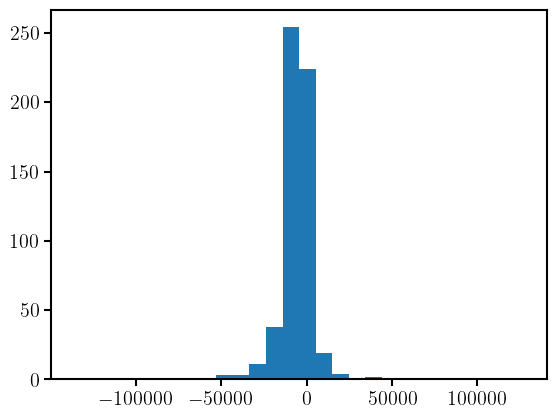

In [24]:
plt.hist(dmean)

(array([  5.,   8.,  10.,  16.,  69., 302., 141.,   6.,   0.,   2.]),
 array([-52424.1015625 , -44106.9453125 , -35789.7890625 , -27472.63085938,
        -19155.47460938, -10838.31835938,  -2521.16162109,   5795.99511719,
         14113.15136719,  22430.30859375,  30747.46484375]),
 <BarContainer object of 10 artists>)

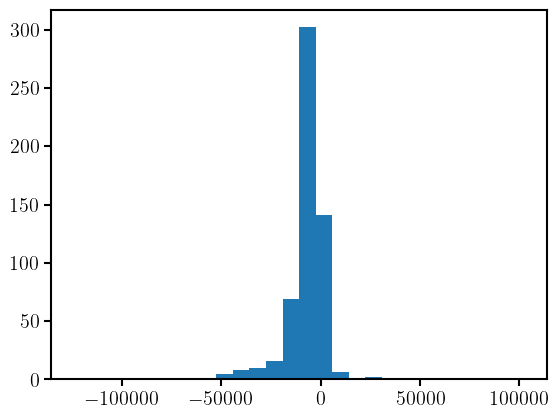

In [25]:
plt.hist(dmedian)

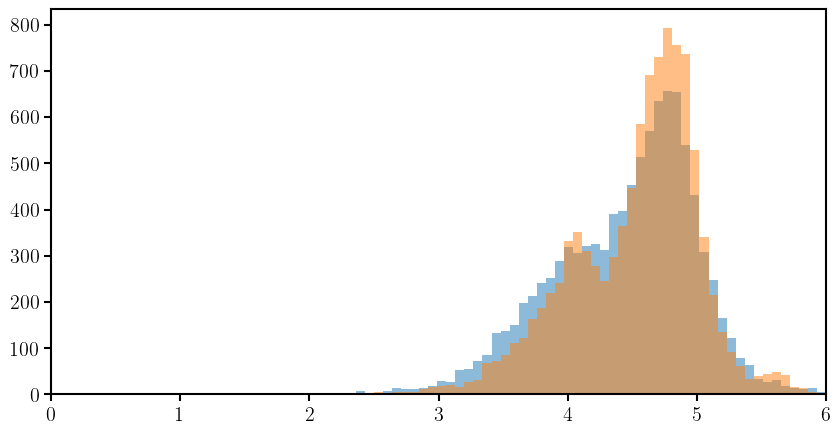

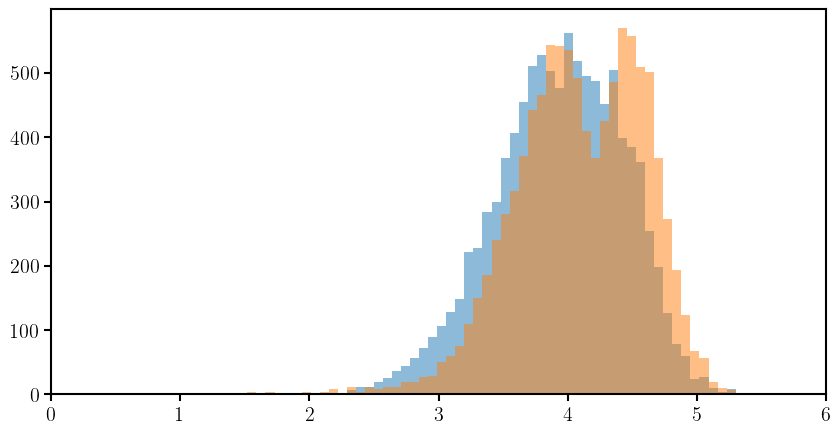

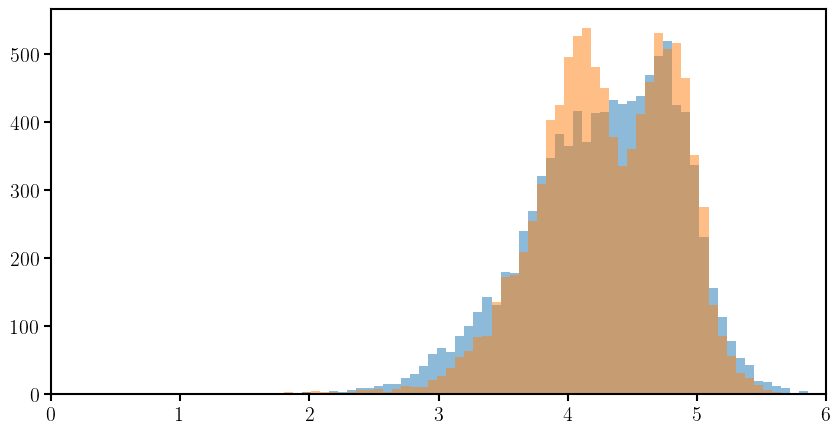

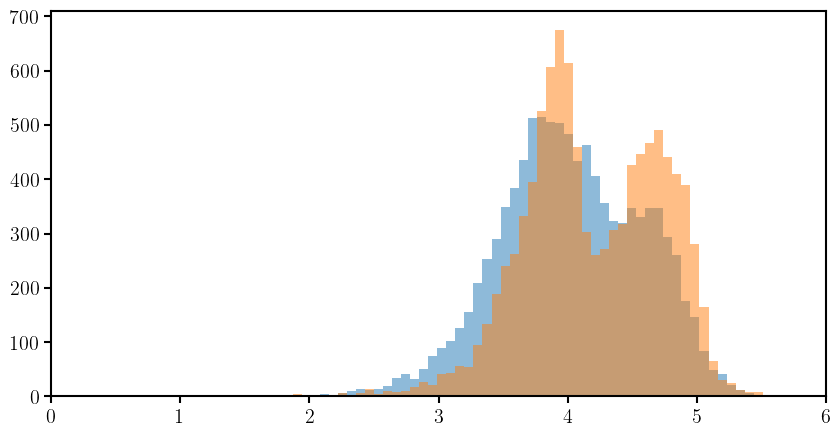

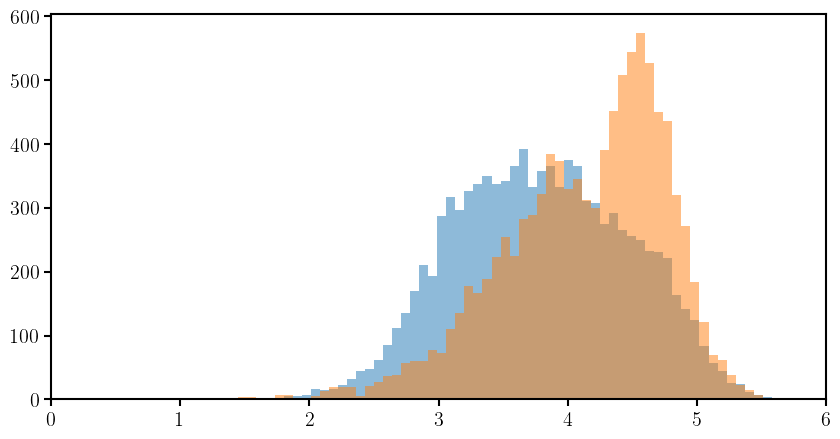

In [20]:
for i in np.random.choice(_data.shape[0], size=5): 
    _X = _data[i,1:]
    logYs_base = Cflow._sample(Cflow.flow_base, _X, Nsample=10000)
    Ys_base = Cflow_nolog._sample(Cflow_nolog.flow_base, _X, Nsample=10000)
        
    fig = plt.figure(figsize=(10,5))
    sub = fig.add_subplot(111)
    #_ = sub.hist(10**logYs_base, color='C0', range=(0., 1e6), bins=100, alpha=0.5)
    #_ = sub.hist(Ys_base, color='C1', range=(0., 1e6), bins=100, alpha=0.5)
    _ = sub.hist(logYs_base, color='C0', range=(-1, 6), bins=100, alpha=0.5)    
    _ = sub.hist(np.log10(Ys_base), color='C1', range=(-1, 6), bins=100, alpha=0.5)
    sub.set_xlim(0, 6.)